# QuickBite Express - Crisis Recovery Analysis

## Notebook 3: RFM Customer Segmentation

RFM segmentation divides customers into meaningful groups 
based on their purchase behavior before and after the crisis.

Recency  : How recently a customer placed an order
Frequency: How many orders a customer placed
Monetary : How much a customer spent in total

This segmentation helps identify which customers can be recovered, 
which are lost, and which are still active.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = "../data/"

orders    = pd.read_csv(BASE_PATH + "fact_orders.csv")
customers = pd.read_csv(BASE_PATH + "dim_customer.csv")

orders['order_timestamp']   = pd.to_datetime(orders['order_timestamp'])
orders['is_cancelled_bool'] = orders['is_cancelled'] == 'Y'

def assign_phase(ts):
    if ts < pd.Timestamp('2025-06-01'):
        return 'Pre-Crisis'
    elif ts < pd.Timestamp('2025-08-01'):
        return 'Crisis'
    else:
        return 'Recovery'

orders['phase'] = orders['order_timestamp'].apply(assign_phase)

print("Data loaded and prepared")

Data loaded and prepared


## RFM Calculation

Calculating Recency, Frequency, and Monetary values 
for each customer based on their complete order history.
Reference date is set to 1st October 2025, one day after 
the last order in the dataset.

In [7]:
# use only non-cancelled orders
orders_clean = orders[orders['is_cancelled_bool'] == False]

# reference date for recency calculation
reference_date = pd.Timestamp('2025-10-01')

rfm = orders_clean.groupby('customer_id').agg(
    recency   = ('order_timestamp', lambda x: (reference_date - x.max()).days),
    frequency = ('order_id', 'count'),
    monetary  = ('total_amount', 'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)

print("RFM Table Sample")
print(rfm.head(10).to_string(index=False))
print("\nTotal customers:", len(rfm))
print("\nRFM Summary Stats")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))
print(f"Note: {107776 - len(rfm)} customers in dim_customer have no order history and are excluded from RFM.")

RFM Table Sample
customer_id  recency  frequency  monetary
 CUST000007      142          1    239.39
 CUST000008      225          1    246.05
 CUST000009       53          3    983.82
 CUST000010      129          3    652.08
 CUST000011      233          1    146.56
 CUST000014       61          1    207.05
 CUST000015      224          1    262.57
 CUST000017      150          1    300.79
 CUST000019      200          1    198.13
 CUST000020      155          3   1139.18

Total customers: 99790

RFM Summary Stats
        recency  frequency  monetary
count  99790.00   99790.00  99790.00
mean     153.50       1.38    486.63
std       72.42       0.65    266.74
min        0.00       1.00    115.06
25%      106.00       1.00    295.84
50%      160.00       1.00    401.52
75%      212.00       2.00    615.40
max      272.00       7.00   2715.18
Note: 7986 customers in dim_customer have no order history and are excluded from RFM.


## RFM Scoring

Each customer is assigned a score of 1 to 3 for each RFM metric.
For Recency, lower days means better score.
For Frequency and Monetary, higher values mean better score.

In [4]:
# recency score - lower recency days is better so reverse scoring
rfm['r_score'] = pd.qcut(rfm['recency'], q=3, labels=[3, 2, 1])

# frequency score - higher is better
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 
                           q=3, labels=[1, 2, 3])

# monetary score - higher is better
rfm['m_score'] = pd.qcut(rfm['monetary'], q=3, labels=[1, 2, 3])

rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)

rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

print("RFM Score Distribution")
print(rfm['rfm_score'].value_counts().sort_index().to_string())

RFM Score Distribution
rfm_score
3     6454
4    17872
5    21599
6    16409
7    11448
8    12344
9    13664


## Customer Segmentation

Customers are grouped into five segments based on their RFM score.
Each segment requires a different recovery strategy.

In [5]:
def assign_segment(score):
    if score >= 8:
        return 'Champions'
    elif score >= 6:
        return 'Loyal'
    elif score >= 5:
        return 'At Risk'
    elif score >= 4:
        return 'Needs Attention'
    else:
        return 'Lost'

rfm['segment'] = rfm['rfm_score'].apply(assign_segment)

segment_summary = rfm.groupby('segment').agg(
    customer_count  = ('customer_id', 'count'),
    avg_recency     = ('recency', 'mean'),
    avg_frequency   = ('frequency', 'mean'),
    avg_monetary    = ('monetary', 'mean')
).reset_index()

segment_summary['avg_recency']   = segment_summary['avg_recency'].round(1)
segment_summary['avg_frequency'] = segment_summary['avg_frequency'].round(2)
segment_summary['avg_monetary']  = segment_summary['avg_monetary'].round(2)

print(segment_summary.to_string(index=False))

        segment  customer_count  avg_recency  avg_frequency  avg_monetary
        At Risk           21599        169.1           1.00        348.10
      Champions           26008        101.6           2.23        804.43
           Lost            6454        233.6           1.00        259.03
          Loyal           27857        133.6           1.22        464.80
Needs Attention           17872        212.2           1.00        307.82


Score 8-9 : Champions        (top performers on all 3 metrics)
Score 6-7 : Loyal            (good on 2 of 3 metrics)
Score 5   : At Risk          (average — declining engagement)
Score 4   : Needs Attention  (below average)
Score 3   : Lost             (lowest on all metrics)

### Chart: Customer Segmentation

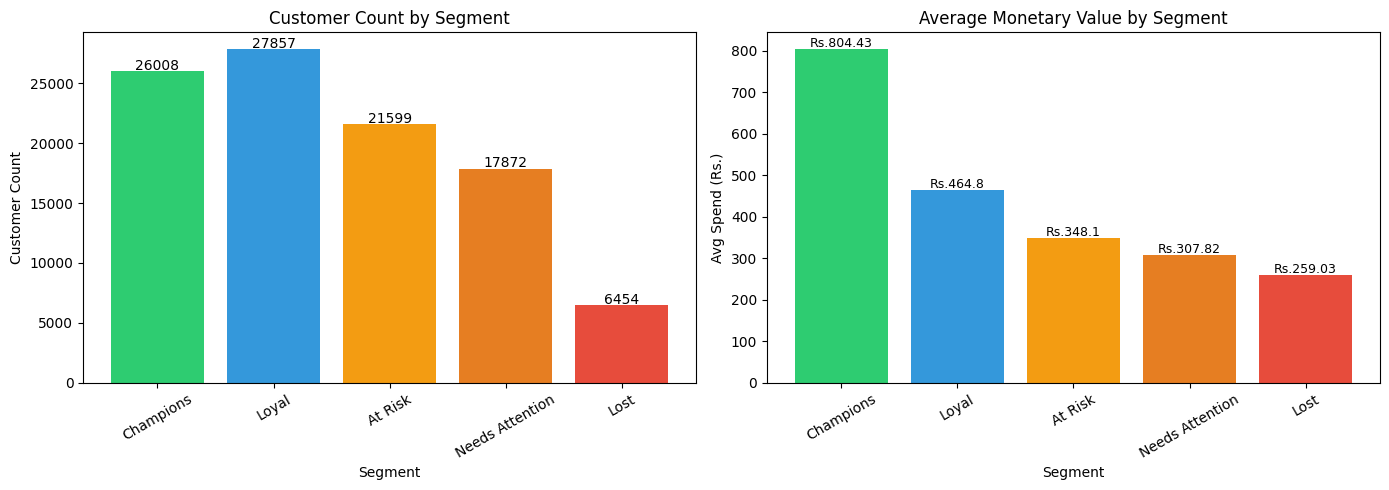

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

segment_order  = ['Champions', 'Loyal', 'At Risk', 'Needs Attention', 'Lost']
colors         = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']

segment_plot = segment_summary.set_index('segment').reindex(segment_order).reset_index()

ax1.bar(segment_plot['segment'], segment_plot['customer_count'], color=colors)
ax1.set_title('Customer Count by Segment')
ax1.set_xlabel('Segment')
ax1.set_ylabel('Customer Count')
ax1.tick_params(axis='x', rotation=30)

for i, val in enumerate(segment_plot['customer_count']):
    ax1.text(i, val + 100, str(val), ha='center')

ax2.bar(segment_plot['segment'], segment_plot['avg_monetary'], color=colors)
ax2.set_title('Average Monetary Value by Segment')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Avg Spend (Rs.)')
ax2.tick_params(axis='x', rotation=30)

for i, val in enumerate(segment_plot['avg_monetary']):
    ax2.text(i, val + 5, f'Rs.{val}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/q_rfm_segmentation.png', dpi=150)
plt.show()

### Observation

Champions (26,008 customers) are the most valuable segment with 
an average spend of Rs. 804 and average recency of 101 days. 
These customers ordered most recently and spent the most. 
They should be rewarded with loyalty programs to retain them.

Loyal customers (27,857) form the largest segment with average 
spend of Rs. 464. These customers have ordered multiple times 
and represent a strong base for recovery.

At Risk customers (21,599) have not ordered recently with an 
average recency of 169 days. They were once active but are 
showing signs of disengagement. Targeted win-back offers 
can bring them back.

Needs Attention customers (17,872) have high recency of 212 days 
meaning they have been inactive for a long time. They need 
stronger incentives to re-engage.

Lost customers (6,454) have the highest recency of 233 days 
and lowest monetary value. These customers are the hardest 
to recover and may require new acquisition strategies.

Total recoverable customers (Champions + Loyal + At Risk): 75,464
These represent the primary target for the recovery campaign.

## RFM Segmentation Summary

99,790 customers were segmented into five groups based on 
their recency, frequency, and monetary behavior.

Champions and Loyal customers together account for 53,865 customers 
and represent the strongest recovery opportunity as they have 
the highest spend and most recent activity.

At Risk customers (21,599) are the most urgent priority as they 
were recently active but showing signs of disengagement. 
A targeted campaign in the next 30 days can prevent them 
from moving to the Lost segment.

Total recoverable customer base is estimated at 75,464 customers 
across Champions, Loyal, and At Risk segments.

This segmentation should be used to design differentiated 
recovery campaigns for each group rather than a single 
platform-wide promotion.